# Project: Customer Segmentation using Agglomerative Hierarchical Clustering

## 🎯 Business Problem

A shopping mall wants to segment customers based on their income and spending behavior to:

- Target marketing campaigns
- Identify high-value customers

## 📂 Dataset

**Mall Customer Segmentation Data (Kaggle)**

**Columns:**

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1–100)

## 🧪 STEP 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 🔍 Explanation

- **pandas** → data loading & manipulation
- **numpy** → numerical operations
- **matplotlib & seaborn** → visualizations

👉 These are standard libraries for any ML project.

## 🧪 STEP 2: Load the Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 🔍 Explanation

- Loads the CSV file into a DataFrame
- `head()` shows first 5 rows so we understand the data structure

📌 At this stage, we inspect column names and values

## 🧪 STEP 3: Basic Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 🔍 Explanation

Shows:

- Column names
- Data types
- Missing values

👉 Agglomerative Clustering cannot handle missing values, so this step is critical.

## 🧪 STEP 4: Select Relevant Features

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 🔍 Explanation

- We exclude CustomerID & Gender
- Clustering works best on numerical features
- These two features clearly represent customer behavior

## 🧪 STEP 5: Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 🔍 Explanation

- `StandardScaler()` converts values to the same scale
- Prevents income dominating spending score
- Distance-based algorithms must be scaled

## 🧪 STEP 6: Create a Dendrogram

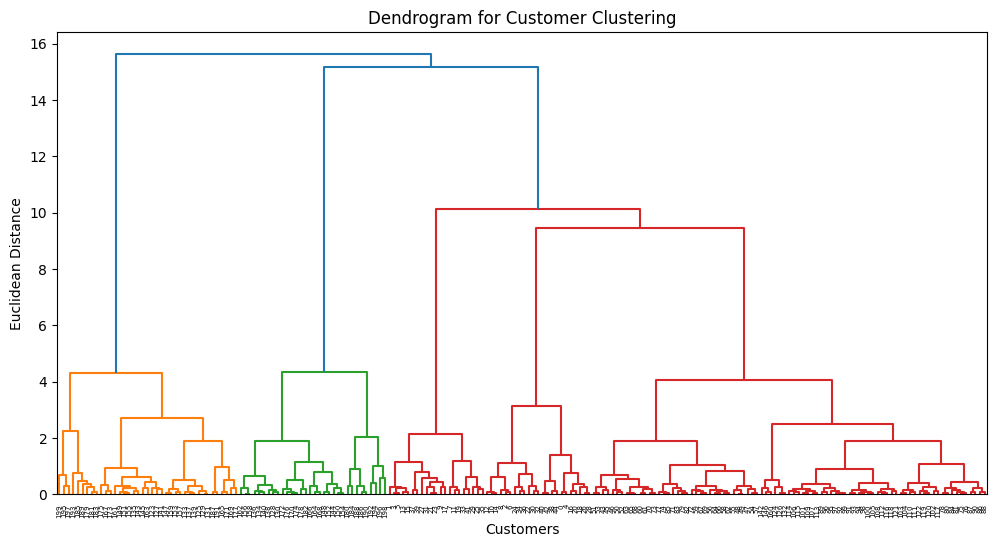

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title('Dendrogram for Customer Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

### 🔍 Explanation (VERY IMPORTANT)

**linkage(X_scaled, method='ward')**
- Computes hierarchical clustering
- Ward method minimizes variance within clusters

**dendrogram(linked)**
- Tree-like diagram
- Shows how clusters merge
- Y-axis = distance

📌 To choose number of clusters:
➡️ Draw a horizontal line where distance jump is maximum

## 🧪 STEP 7: Decide Number of Clusters

From the dendrogram, we choose:

👉 **5 clusters**

## 🧪 STEP 8: Apply Agglomerative Clustering

In [7]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

clusters = model.fit_predict(X_scaled)

### 🔍 Explanation

- `n_clusters=5` → based on dendrogram
- `metric='euclidean'` → distance calculation
- `fit_predict()` → fits model & assigns cluster labels

## 🧪 STEP 9: Add Cluster Labels to Dataset

In [8]:
df['Cluster'] = clusters
df.head(15)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
5,6,Female,22,17,76,3
6,7,Female,35,18,6,4
7,8,Female,23,18,94,3
8,9,Male,64,19,3,4
9,10,Female,30,19,72,3


### 🔍 Explanation

- Adds a new column showing cluster assignment
- Each customer now belongs to a group (0–4)

## 🧪 STEP 10: Visualize the Clusters

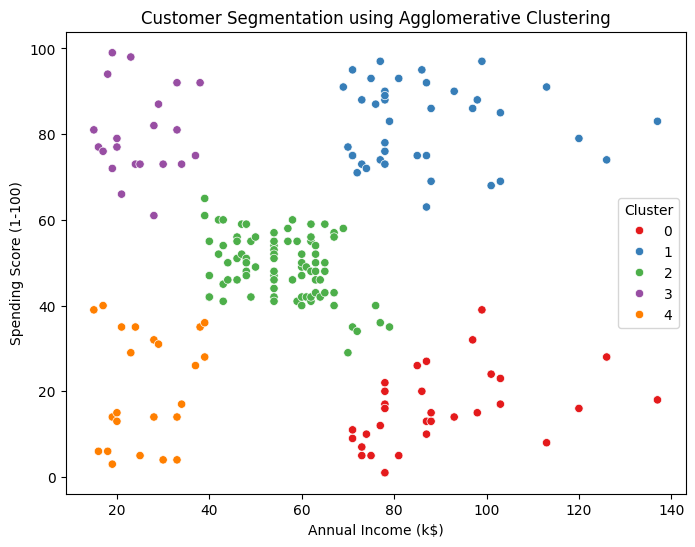

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title('Customer Segmentation using Agglomerative Clustering')
plt.show()

### 🔍 Explanation

- Scatter plot shows customer groups visually
- Each color = one cluster
- Easy to interpret business behavior

## 🧪 STEP 11: Cluster Interpretation

In [10]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043


### 🔍 Explanation

- Calculates average behavior per cluster
- Helps convert ML output into business insights

## 📊 Sample Business Insights

| Cluster | Income Level  | Spending Level  | Cluster Type                          | Interpretation                                                                                                        |
| ------- | ------------- | --------------- | ------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **0**   | High Income   | Low Spending    | **High Income + Low Spending**        | **Potential Targets** – wealthy customers who spend cautiously; good candidates for upselling and personalized offers |
| **1**   | High Income   | High Spending   | **High Income + High Spending**       | **Premium Customers** – most valuable segment; loyal, high revenue contributors                                       |
| **2**   | Medium Income | Medium Spending | **Average Income + Average Spending** | **Standard Customers** – balanced behavior; stable and consistent                                                     |
| **3**   | Low Income    | High Spending   | **Low Income + High Spending**        | **Discount Seekers** – price-sensitive but highly engaged; respond well to promotions                                 |
| **4**   | Low Income    | Low Spending    | **Low Income + Low Spending**         | **Low Priority Customers** – minimal engagement and low revenue potential                                             |


## 🧠 Why Agglomerative Clustering Here?

✔ No need to predefine K initially  
✔ Dendrogram gives visual explanation  
✔ Highly interpretable  
✔ Works well for small–medium datasets